# Multimodal Learning Assignment

### <img src="https://cdn-icons-png.flaticon.com/512/1373/1373613.png" width="20" height="20" /> <font face="Roboto" color='#76b900'>David Ortiz Pérez</font> <font face="Roboto" size=3 color='#404040'>(*dortiz@dtic.ua.es*)</font>

###  <img src="https://cdn-icons-png.flaticon.com/512/1373/1373613.png" width="20" height="20" /><font face="Roboto" color='#76b900'> Manuel Benavent Lledó</font> <font face="Roboto" size=3 color='#404040'>(*mbenavent@dtic.ua.es*)</font>

# Assignment Information

Grade ponderation:
- 25% Correctly building the dataloaders (Adding the textual information).
- 25% Proposing a text-based model.
- 20% Proposing a multimodal model.
- 5% if the full pipeline correctly works.
- 5% Rank of best accuracies (The best accuracies will obtain a 5%, the others will be gradually decreasing).
- Adding new features or improvements (5% each, max 20%):
  - Experimenting with other vision or text models (e.g. ViT).
  - Weight & Biases logger (include code and screenshots).
  - Experimenting with other fusion strategies.
  - Create a table resembling the one depicted in the figure. Include various images from the test set alongside the output of each model or modality. Briefly explain the rationale behind the prediction made by each modality in the respective case (keep explanations very concise).
  - Use a pretrained multimodal model, for example VisualBERT, for vision and language, and fine-tune it.
  - Data augmentation experiments.
  - Obtain text modality from the images (not using the text column of the CSV).
  - Others (previous approval by us).

**Maximum of 10 points**

Please mark each completed item with a ✅. Note that we will **ONLY** look for the checked items in the file. You can add additional **SHORT** comments next to the checkmark (e.g. half completed or implemented but didn't work).

# Dataset information

Title: Multimodal Meme Dataset (MultiOFF) for Identifying Offensive Content in Image and Text

Link to paper: https://aclanthology.org/2020.trac-1.6/

Modalities: Image and Text

Information: Image of the meme and its caption

Labels: Offensive and non-offensive

Binary classification task



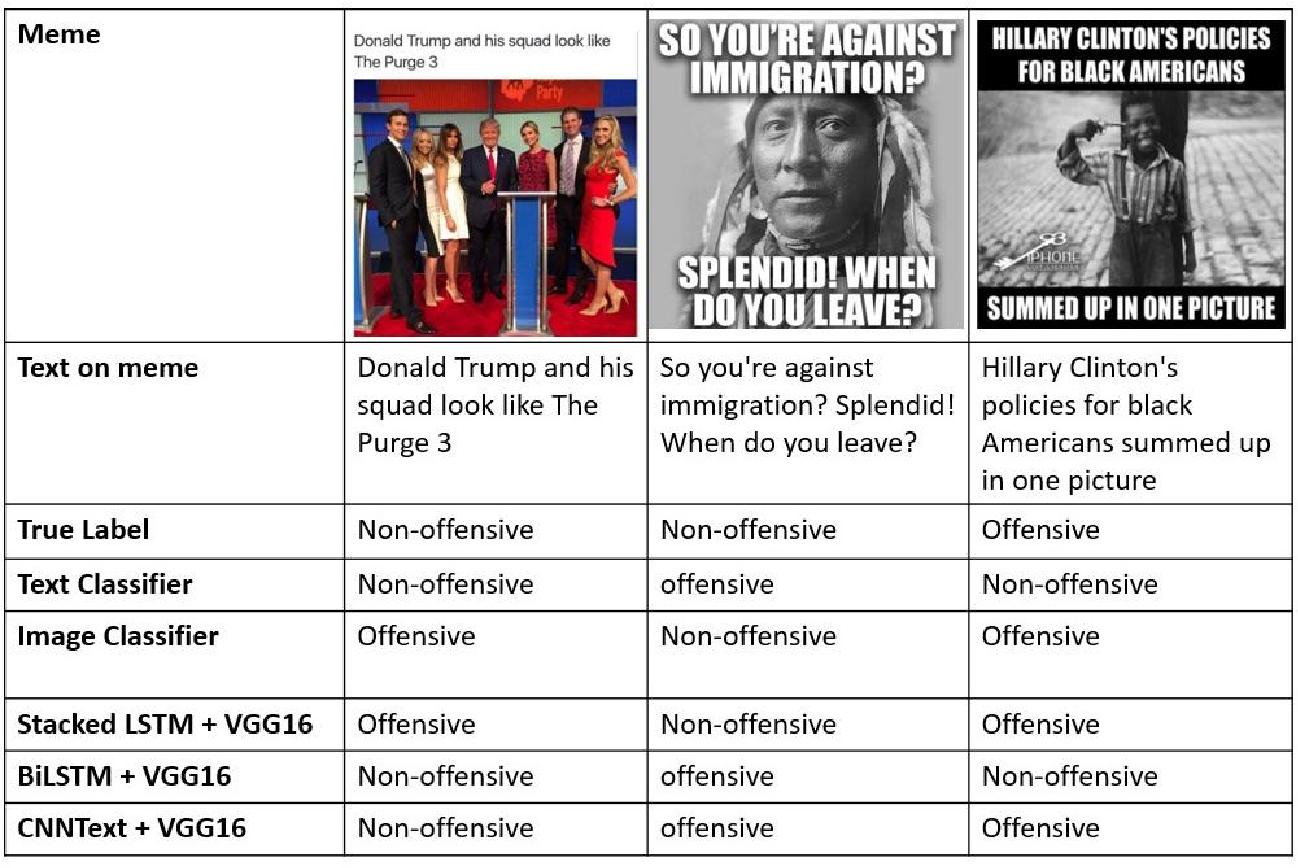


Baseline pipeline presented by authors:

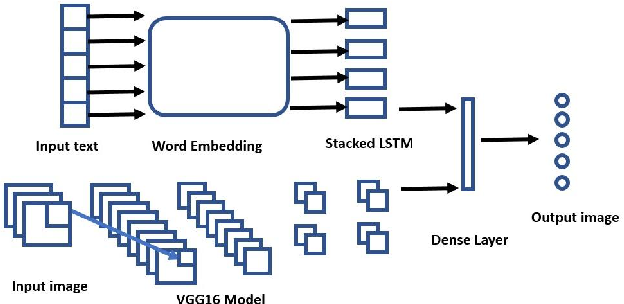

Obtained results:

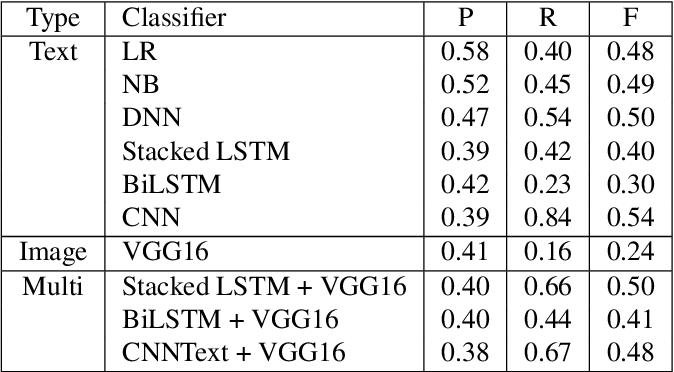

# This is a basic structure for the practice, any change that benefit the results will be welcome

# Download dataset from Google Drive and extract the zip

Link: https://drive.google.com/drive/folders/1hKLOtpVmF45IoBmJPwojgq6XraLtHmV6

In [1]:
# CELL 1: install_dependencies_and_download_dataset
# Description: Installs all required libraries, downloads the dataset from Google Drive,
# and extracts it into /content if it is not already available.

!pip -q install gdown transformers scikit-learn pillow tqdm

import os

DATASET_ZIP_PATH = "/content/dataset.zip"

if not os.path.exists(DATASET_ZIP_PATH):
    !gdown 1hwEZylqwwecrwyBsl4vgSbHTW9pJ54RK -O {DATASET_ZIP_PATH}

if not os.path.exists("/content/Labelled Images") or not os.path.exists("/content/Split Dataset"):
    !unzip -qo {DATASET_ZIP_PATH} -d /content

!pip -q install -U transformers

Downloading...
From (original): https://drive.google.com/uc?id=1hwEZylqwwecrwyBsl4vgSbHTW9pJ54RK
From (redirected): https://drive.google.com/uc?id=1hwEZylqwwecrwyBsl4vgSbHTW9pJ54RK&confirm=t&uuid=86958c73-9592-4006-bb5a-f801082efd8d
To: /content/dataset.zip
100% 228M/228M [00:00<00:00, 248MB/s]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 50.0 MB/s eta 0:00:00


# Import libraries

Todo:
- Add the necessary libraries that have been used

In [11]:
# CELL 2: imports_and_global_configuration
# Description: Imports all required libraries and defines the global configuration,
# paths, seeds, and training hyperparameters.

import os
import random
import time
import html
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display, HTML

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import v2
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import AutoTokenizer, AutoModel


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Paths
csv_train_file = '/content/Split Dataset/Training_meme_dataset.csv'
csv_test_file = '/content/Split Dataset/Testing_meme_dataset.csv'
csv_valid_file = '/content/Split Dataset/Validation_meme_dataset.csv'
root_image_folder_path = '/content/Labelled Images/'

MODELS_DIR = Path("/content/models")
RESULTS_DIR = Path("/content/results")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Model names
TEXT_MODEL_NAME = "distilbert-base-uncased"

# Hyperparameters
MAX_TEXT_LEN = 64
NUM_WORKERS = 0
PATIENCE = 3

IMAGE_BATCH_SIZE = 32
TEXT_BATCH_SIZE = 16
MULTIMODAL_BATCH_SIZE = 8
FEATURE_BATCH_SIZE = 64

IMAGE_LR = 1e-3
TEXT_LR = 2e-5
MULTIMODAL_LR = 2e-4
FEATURE_LR = 1e-3

N_EPOCHS = 8

# Label names kept aligned with the original skeleton
labels = ['Non-offensiv', 'offensive']

# Alias map to make the code robust to minor label variations in the CSV
label_to_idx = {
    'Non-offensiv': 0,
    'non-offensiv': 0,
    'Non-offensive': 0,
    'non-offensive': 0,
    'non offensive': 0,
    'offensive': 1,
    'Offensive': 1
}
idx_to_label = {0: 'Non-offensiv', 1: 'offensive'}

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

Using device: cuda


In [24]:
# CELL 3: helper_functions_for_splits_and_labels
# Description: Defines helper functions for label normalization, path resolution,
# split parsing, and quick dataset inspection.

def normalize_label_value(value):
    value = str(value).strip().lower().replace("-", " ").replace("_", " ")
    value = " ".join(value.split())

    if "non" in value:
        return 0
    if "offens" in value:
        return 1

    raise ValueError(f"Unknown label value found in CSV: {value}")


def resolve_image_path(image_name):
    return os.path.join(root_image_folder_path, str(image_name))


def build_split_lists(file_name):
    data = pd.read_csv(file_name)

    image_paths = []
    labels_list = []
    texts = []
    image_names = []

    for _, row in data.iterrows():
        image_path = resolve_image_path(row['image_name'])

        # Keep the exclusion already present in the original skeleton
        if image_path == '/content/Labelled Images/KbTk7Rq.png':
            continue


        if not os.path.exists(image_path):
            continue

        image_paths.append(image_path)
        labels_list.append(normalize_label_value(row['label']))
        texts.append("" if pd.isna(row['sentence']) else str(row['sentence']))
        image_names.append(str(row['image_name']))

    return image_paths, labels_list, texts, image_names


def summarize_split(file_name, split_name):
    image_paths, labels_list, texts, image_names = build_split_lists(file_name)
    distribution = pd.Series(labels_list).value_counts().sort_index()
    print(f"{split_name} split")
    print(f"  Samples: {len(labels_list)}")
    print(f"  Non-offensive: {distribution.get(0, 0)}")
    print(f"  Offensive: {distribution.get(1, 0)}")
    print()


summarize_split(csv_train_file, "Train")
summarize_split(csv_valid_file, "Validation")
summarize_split(csv_test_file, "Test")

Train split
  Samples: 445
  Non-offensive: 258
  Offensive: 187

Validation split
  Samples: 148
  Non-offensive: 91
  Offensive: 57

Test split
  Samples: 149
  Non-offensive: 91
  Offensive: 58



# Generate custom dataset class

Todo:
- Check which variables are going to be used and stored
- Check which data transformations must be performed and when
- Obtain the validation and test dataloaders as well

Tips:
- Load images from the image paths in the CSV and do operations like resize, central crop, normalization, etc.
- Obtain embeddings for the text (Bert embeddings for example)
- Note that the CSV contains another column of data which is 'sentence', which is the text of the picture
-  This is not a must-follow structure, the implementation can change depending on the problem (for example loading the CSV file from the init in the dataset class, if more than one dataset is going to be used)

In [13]:
# CELL 4: dataset_classes
# Description: Implements the main dataset classes for image-only, text-only,
# multimodal, and precomputed-feature settings.

class custom_dataset(Dataset):
    def __init__(self, image_paths, labels, texts=None, tokenizer=None, return_text=False):
        self.image_paths = image_paths
        self.labels = labels
        self.texts = texts
        self.tokenizer = tokenizer
        self.return_text = return_text

        self.transforms = v2.Compose([
            v2.Resize(size=(224, 224)),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
        ])

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = self.transforms(image)

        label = torch.tensor(self.labels[idx]).float()

        if self.return_text:
            text = self.texts[idx]
            encoded_text = self.tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=MAX_TEXT_LEN,
                return_tensors="pt"
            )
            encoded_text = {k: v.squeeze(0) for k, v in encoded_text.items()}
            return image, encoded_text, label

        return image, label


class custom_text_dataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoded_text = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )
        encoded_text = {k: v.squeeze(0) for k, v in encoded_text.items()}
        label = torch.tensor(self.labels[idx]).float()
        return encoded_text, label


class custom_dataset_features(Dataset):
    def __init__(self, image_paths, labels, texts=None, tokenizer=None, return_text=False):
        self.image_paths = image_paths
        self.labels = labels
        self.texts = texts
        self.tokenizer = tokenizer
        self.return_text = return_text

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        feature_path = self.image_paths[idx][:-4] + '.pt'
        image = torch.load(feature_path, map_location='cpu').float()

        label = torch.tensor(self.labels[idx]).float()

        if self.return_text:
            text = self.texts[idx]
            encoded_text = self.tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=MAX_TEXT_LEN,
                return_tensors="pt"
            )
            encoded_text = {k: v.squeeze(0) for k, v in encoded_text.items()}
            return image, encoded_text, label

        return image, label

In [14]:
# CELL 5: dataloaders_for_all_experiments
# Description: Builds train, validation, and test dataloaders for image-only,
# text-only, multimodal, and precomputed-feature experiments.

def get_dataloaders(mode="image", batch_size=32):
    train_image_paths, train_labels, train_texts, _ = build_split_lists(csv_train_file)
    valid_image_paths, valid_labels, valid_texts, _ = build_split_lists(csv_valid_file)
    test_image_paths, test_labels, test_texts, _ = build_split_lists(csv_test_file)

    if mode == "image":
        train_dataset = custom_dataset(train_image_paths, train_labels)
        valid_dataset = custom_dataset(valid_image_paths, valid_labels)
        test_dataset = custom_dataset(test_image_paths, test_labels)

    elif mode == "text":
        train_dataset = custom_text_dataset(train_texts, train_labels, tokenizer)
        valid_dataset = custom_text_dataset(valid_texts, valid_labels, tokenizer)
        test_dataset = custom_text_dataset(test_texts, test_labels, tokenizer)

    elif mode == "multimodal":
        train_dataset = custom_dataset(train_image_paths, train_labels, train_texts, tokenizer, return_text=True)
        valid_dataset = custom_dataset(valid_image_paths, valid_labels, valid_texts, tokenizer, return_text=True)
        test_dataset = custom_dataset(test_image_paths, test_labels, test_texts, tokenizer, return_text=True)

    elif mode == "features":
        train_dataset = custom_dataset_features(train_image_paths, train_labels)
        valid_dataset = custom_dataset_features(valid_image_paths, valid_labels)
        test_dataset = custom_dataset_features(test_image_paths, test_labels)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    train_data_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    valid_data_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_data_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_data_loader, valid_data_loader, test_data_loader

# Define the models

Todo:
- Adapt the model parameters for its convenient data type that are going to process

Tips:
- It is a simple MLP (just for an example), use other architectures
- Use of transformers for the text modality
- Use of CNNs or transformers for image modality
- Try to use other fusion strategy, late fusion(very simple), cross-modal, etc.

In [15]:
# CELL 6: model_definitions
# Description: Defines the image-only, text-only, multimodal early-fusion,
# and feature-based classification models.

class unimodal_model(nn.Module):
    def __init__(self):
        super(unimodal_model, self).__init__()

        self.feature_extractor = resnet50(weights=ResNet50_Weights.DEFAULT)
        n_features = self.feature_extractor.fc.in_features
        self.feature_extractor.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

        # Freeze the feature extractor
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, src):
        src = self.feature_extractor(src)
        output = self.classifier(src)
        return output


class text_unimodal_model(nn.Module):
    def __init__(self, text_model_name=TEXT_MODEL_NAME, freeze_text_encoder=True):
        super(text_unimodal_model, self).__init__()

        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        hidden_size = self.text_encoder.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

        if freeze_text_encoder:
            for param in self.text_encoder.parameters():
                param.requires_grad = False

    def forward(self, src):
        encoded = self.text_encoder(**src)
        pooled_output = encoded.last_hidden_state[:, 0, :]
        output = self.classifier(pooled_output)
        return output

In [16]:
# CELL 6.2: model_definitions

class multimodal_early_modal(nn.Module):
    def __init__(self, n_features=1000, n_modalities=2, text_model_name=TEXT_MODEL_NAME):
        super(multimodal_early_modal, self).__init__()

        self.image_feature_extractor = resnet50(weights=ResNet50_Weights.DEFAULT)
        image_feature_dim = self.image_feature_extractor.fc.in_features
        self.image_feature_extractor.fc = nn.Identity()

        self.text_feature_extractor = AutoModel.from_pretrained(text_model_name)
        text_feature_dim = self.text_feature_extractor.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(image_feature_dim + text_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

        for param in self.image_feature_extractor.parameters():
            param.requires_grad = False

        for param in self.text_feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, src_modality_1, src_modality_2):
        image_features = self.image_feature_extractor(src_modality_1)
        text_outputs = self.text_feature_extractor(**src_modality_2)
        text_features = text_outputs.last_hidden_state[:, 0, :]

        src = torch.cat((image_features, text_features), 1)
        output = self.classifier(src)
        return output


class unimodal_model_features(nn.Module):
    def __init__(self, n_features=2048):
        super(unimodal_model_features, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, src):
        output = self.classifier(src)
        return output

# Train structure

Todo:
- Calculate the metrics of the model (accuracy and F1)
- Develop a validation strategy to store the model that better works
- Test the best model over the test set



In [17]:
# CELL 7: training_validation_and_testing_utilities
# Description: Implements reusable functions for training, validation,
# checkpointing, early stopping, and final test evaluation.

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "y_pred": y_pred.tolist()
    }


def forward_batch(model, batch, mode):
    if mode == "image":
        src, tgt = batch
        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)
        output = model(src).squeeze(1)

    elif mode == "text":
        src, tgt = batch
        src = {k: v.to(device, non_blocking=True) for k, v in src.items()}
        tgt = tgt.to(device, non_blocking=True)
        output = model(src).squeeze(1)

    elif mode == "multimodal":
        src_modality_1, src_modality_2, tgt = batch
        src_modality_1 = src_modality_1.to(device, non_blocking=True)
        src_modality_2 = {k: v.to(device, non_blocking=True) for k, v in src_modality_2.items()}
        tgt = tgt.to(device, non_blocking=True)
        output = model(src_modality_1, src_modality_2).squeeze(1)

    elif mode == "features":
        src, tgt = batch
        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)
        output = model(src).squeeze(1)

    else:
        raise ValueError(f"Unsupported mode: {mode}")

    return output, tgt


def run_epoch(model, data_loader, loss_function, mode, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    epoch_loss = 0.0
    all_targets = []
    all_probs = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for batch in tqdm(data_loader, leave=False):
            output, tgt = forward_batch(model, batch, mode)
            loss = loss_function(output, tgt)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item() * tgt.size(0)
            all_targets.extend(tgt.detach().cpu().numpy().astype(int).tolist())
            all_probs.extend(output.detach().cpu().numpy().tolist())

    metric_dict = compute_metrics(all_targets, all_probs)
    metric_dict["loss"] = epoch_loss / max(len(data_loader.dataset), 1)
    metric_dict["y_true"] = all_targets
    metric_dict["y_prob"] = all_probs

    return metric_dict


def fit_model(model, train_data_loader, valid_data_loader, optimizer, loss_function, n_epochs, model_name, mode):
    best_val_f1 = -1.0
    epochs_without_improvement = 0
    history = []

    best_model_path = MODELS_DIR / f"{model_name}.pt"

    for epoch in range(n_epochs):
        init_time = time.time()

        train_metrics = run_epoch(
            model=model,
            data_loader=train_data_loader,
            loss_function=loss_function,
            mode=mode,
            optimizer=optimizer
        )

        valid_metrics = run_epoch(
            model=model,
            data_loader=valid_data_loader,
            loss_function=loss_function,
            mode=mode,
            optimizer=None
        )

        epoch_time = time.time() - init_time

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "valid_loss": valid_metrics["loss"],
            "valid_accuracy": valid_metrics["accuracy"],
            "valid_f1": valid_metrics["f1"],
            "epoch_time_sec": epoch_time
        })

        print(
            f"Epoch {epoch + 1}/{n_epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"train_f1={train_metrics['f1']:.4f} | "
            f"valid_loss={valid_metrics['loss']:.4f} | "
            f"valid_acc={valid_metrics['accuracy']:.4f} | "
            f"valid_f1={valid_metrics['f1']:.4f} | "
            f"time={epoch_time:.2f}s"
        )

        if valid_metrics["f1"] > best_val_f1:
            best_val_f1 = valid_metrics["f1"]
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  -> Best model updated and saved to: {best_model_path}")
        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement. Patience: {epochs_without_improvement}/{PATIENCE}")

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"{model_name}_history.csv", index=False)

    return best_model_path, history_df


def test_best_model(model, best_model_path, test_data_loader, loss_function, mode, model_name):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    test_metrics = run_epoch(
        model=model,
        data_loader=test_data_loader,
        loss_function=loss_function,
        mode=mode,
        optimizer=None
    )

    print(f"\nTest results for {model_name}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"F1: {test_metrics['f1']:.4f}\n")

    print(classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=[idx_to_label[0], idx_to_label[1]],
        zero_division=0
    ))

    return test_metrics

In [18]:
# CELL 8: train_unimodal_cnn_rgb_model
# Description: Trains the ResNet50-based image-only model using RGB images,
# performs validation with checkpointing, and evaluates the best model on the test set.

n_epochs = N_EPOCHS

model = unimodal_model().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=IMAGE_LR)
loss_function = nn.BCELoss()

train_data_loader, valid_data_loader, test_data_loader = get_dataloaders(
    mode="image",
    batch_size=IMAGE_BATCH_SIZE
)

image_best_model_path, image_history = fit_model(
    model=model,
    train_data_loader=train_data_loader,
    valid_data_loader=valid_data_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    n_epochs=n_epochs,
    model_name="unimodal_cnn_rgb",
    mode="image"
)

image_test_metrics = test_best_model(
    model=model,
    best_model_path=image_best_model_path,
    test_data_loader=test_data_loader,
    loss_function=loss_function,
    mode="image",
    model_name="unimodal_cnn_rgb"
)

display(image_history)

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/8 | train_loss=0.7066 | train_acc=0.5124 | train_f1=0.2694 | valid_loss=0.6599 | valid_acc=0.6149 | valid_f1=0.2785 | time=11.80s
  -> Best model updated and saved to: /content/models/unimodal_cnn_rgb.pt


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 5/8 | train_loss=0.4025 | train_acc=0.8270 | train_f1=0.7819 | valid_loss=0.9013 | valid_acc=0.6216 | valid_f1=0.0968 | time=11.90s
  -> No improvement. Patience: 3/3
Early stopping triggered.


  0%|          | 0/5 [00:00<?, ?it/s]


Test results for unimodal_cnn_rgb
Accuracy: 0.5369
F1: 0.4964

              precision    recall  f1-score   support

Non-offensiv       0.66      0.51      0.57        91
   offensive       0.43      0.59      0.50        58

    accuracy                           0.54       149
   macro avg       0.54      0.55      0.53       149
weighted avg       0.57      0.54      0.54       149



,epoch,train_loss,train_accuracy,train_f1,valid_loss,valid_accuracy,valid_f1,epoch_time_sec
0,1,0.706576,0.512360,0.269360,0.659891,0.614865,0.278481,11.802097
1,2,0.601446,0.665169,0.473498,0.705033,0.486486,0.449275,11.910710
2,3,0.506614,0.795506,0.723404,0.712394,0.554054,0.421053,11.905280
3,4,0.481026,0.773034,0.720222,0.756758,0.601351,0.233766,11.852854
4,5,0.402525,0.826966,0.781870,0.901283,0.621622,0.096774,11.896926


In [19]:
# CELL 9: train_unimodal_text_model
# Description: Trains a DistilBERT-based text-only model on the meme captions,
# validates it, and evaluates the best checkpoint on the test set.

text_model = text_unimodal_model().to(device)
text_optimizer = torch.optim.Adam(text_model.parameters(), lr=TEXT_LR)
text_loss_function = nn.BCELoss()

train_text_loader, valid_text_loader, test_text_loader = get_dataloaders(
    mode="text",
    batch_size=TEXT_BATCH_SIZE
)

text_best_model_path, text_history = fit_model(
    model=text_model,
    train_data_loader=train_text_loader,
    valid_data_loader=valid_text_loader,
    optimizer=text_optimizer,
    loss_function=text_loss_function,
    n_epochs=n_epochs,
    model_name="unimodal_bert_text",
    mode="text"
)

text_test_metrics = test_best_model(
    model=text_model,
    best_model_path=text_best_model_path,
    test_data_loader=test_text_loader,
    loss_function=text_loss_function,
    mode="text",
    model_name="unimodal_bert_text"
)

display(text_history)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 4/8 | train_loss=0.6783 | train_acc=0.5798 | train_f1=0.0000 | valid_loss=0.6705 | valid_acc=0.6149 | valid_f1=0.0000 | time=1.40s
  -> No improvement. Patience: 3/3
Early stopping triggered.


  0%|          | 0/10 [00:00<?, ?it/s]


Test results for unimodal_bert_text
Accuracy: 0.6107
F1: 0.0000

              precision    recall  f1-score   support

Non-offensiv       0.61      1.00      0.76        91
   offensive       0.00      0.00      0.00        58

    accuracy                           0.61       149
   macro avg       0.31      0.50      0.38       149
weighted avg       0.37      0.61      0.46       149



,epoch,train_loss,train_accuracy,train_f1,valid_loss,valid_accuracy,valid_f1,epoch_time_sec
0,1,0.693127,0.498876,0.326284,0.680643,0.614865,0.0,1.525539
1,2,0.682750,0.579775,0.000000,0.675435,0.614865,0.0,1.261024
2,3,0.679937,0.579775,0.000000,0.671751,0.614865,0.0,1.240012
3,4,0.678264,0.579775,0.000000,0.670511,0.614865,0.0,1.399755


In [20]:
# CELL 10: train_multimodal_early_fusion_model
# Description: Trains a multimodal early-fusion model that combines ResNet50 image
# features with DistilBERT text features, then evaluates it on the test split.

multimodal_model = multimodal_early_modal().to(device)
multimodal_optimizer = torch.optim.Adam(multimodal_model.parameters(), lr=MULTIMODAL_LR)
multimodal_loss_function = nn.BCELoss()

train_multi_loader, valid_multi_loader, test_multi_loader = get_dataloaders(
    mode="multimodal",
    batch_size=MULTIMODAL_BATCH_SIZE
)

multimodal_best_model_path, multimodal_history = fit_model(
    model=multimodal_model,
    train_data_loader=train_multi_loader,
    valid_data_loader=valid_multi_loader,
    optimizer=multimodal_optimizer,
    loss_function=multimodal_loss_function,
    n_epochs=n_epochs,
    model_name="multimodal_early_fusion",
    mode="multimodal"
)

multimodal_test_metrics = test_best_model(
    model=multimodal_model,
    best_model_path=multimodal_best_model_path,
    test_data_loader=test_multi_loader,
    loss_function=multimodal_loss_function,
    mode="multimodal",
    model_name="multimodal_early_fusion"
)

display(multimodal_history)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1/8 | train_loss=0.6941 | train_acc=0.5685 | train_f1=0.2320 | valid_loss=0.6658 | valid_acc=0.6284 | valid_f1=0.0678 | time=14.70s
  -> Best model updated and saved to: /content/models/multimodal_early_fusion.pt


...

  0%|          | 0/19 [00:00<?, ?it/s]

Epoch 8/8 | train_loss=0.4769 | train_acc=0.7820 | train_f1=0.7342 | valid_loss=0.7482 | valid_acc=0.6014 | valid_f1=0.1194 | time=15.39s
  -> No improvement. Patience: 1/3


  0%|          | 0/19 [00:00<?, ?it/s]


Test results for multimodal_early_fusion
Accuracy: 0.6443
F1: 0.6074

              precision    recall  f1-score   support

Non-offensiv       0.76      0.60      0.67        91
   offensive       0.53      0.71      0.61        58

    accuracy                           0.64       149
   macro avg       0.65      0.66      0.64       149
weighted avg       0.67      0.64      0.65       149



,epoch,train_loss,train_accuracy,train_f1,valid_loss,valid_accuracy,valid_f1,epoch_time_sec
0,1,0.694112,0.568539,0.232000,0.665758,0.628378,0.067797,14.696339
1,2,0.657403,0.647191,0.353909,0.659879,0.621622,0.066667,15.158891
2,3,0.625301,0.644944,0.414815,0.670079,0.554054,0.340000,14.569249
3,4,0.615069,0.662921,0.482759,0.668996,0.567568,0.255814,14.215190
4,5,0.582015,0.707865,0.603659,0.674578,0.554054,0.282609,14.496391
5,6,0.538263,0.757303,0.670732,0.704637,0.506757,0.396694,14.848190
6,7,0.509943,0.764045,0.680851,0.708758,0.540541,0.492537,14.656686
7,8,0.476902,0.782022,0.734247,0.748193,0.601351,0.119403,15.385237


# Previous Feature Extraction

You can extract features in a preprocess step instead of in the training loop, having an improvement in the training time.

In [21]:
# CELL 11: precompute_cnn_features
# Description: Extracts and stores ResNet50 feature vectors for all images in the
# train, validation, and test splits to speed up later training.

def obtain_cnn_features(file_name):
    data = pd.read_csv(file_name)

    feature_extractor = resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    feature_extractor.fc = nn.Identity()
    feature_extractor.eval()

    transforms = v2.Compose([
        v2.Resize(size=(224, 224)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
    ])

    with torch.no_grad():
        for _, row in tqdm(data.iterrows(), total=len(data), desc=f"Extracting features from {Path(file_name).name}"):
            image_path = root_image_folder_path + row['image_name']

            if image_path == '/content/Labelled Images/KbTk7Rq.png':
                continue

            if not os.path.exists(image_path):
                continue

            feature_path = image_path[:-4] + '.pt'
            if os.path.exists(feature_path):
                continue

            image = Image.open(image_path).convert("RGB")
            image = transforms(image).unsqueeze(dim=0).to(device)

            features = feature_extractor(image).squeeze(0).cpu()
            torch.save(features, feature_path)


obtain_cnn_features(csv_train_file)
obtain_cnn_features(csv_valid_file)
obtain_cnn_features(csv_test_file)

Extracting features from Training_meme_dataset.csv:   0%|          | 0/445 [00:00<?, ?it/s]

Extracting features from Validation_meme_dataset.csv:   0%|          | 0/149 [00:00<?, ?it/s]

Extracting features from Testing_meme_dataset.csv:   0%|          | 0/149 [00:00<?, ?it/s]

In [22]:
# CELL 12: train_unimodal_model_with_precomputed_features
# Description: Trains a lightweight classifier on the precomputed CNN features,
# validates it, and evaluates the best checkpoint on the test split.

n_epochs = N_EPOCHS

model = unimodal_model_features(n_features=2048).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=FEATURE_LR)
loss_function = nn.BCELoss()

train_data_loader, valid_data_loader, test_data_loader = get_dataloaders(
    mode="features",
    batch_size=FEATURE_BATCH_SIZE
)

feature_best_model_path, feature_history = fit_model(
    model=model,
    train_data_loader=train_data_loader,
    valid_data_loader=valid_data_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    n_epochs=n_epochs,
    model_name="unimodal_cnn_precomputed_features",
    mode="features"
)

feature_test_metrics = test_best_model(
    model=model,
    best_model_path=feature_best_model_path,
    test_data_loader=test_data_loader,
    loss_function=loss_function,
    mode="features",
    model_name="unimodal_cnn_precomputed_features"
)

display(feature_history)

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/8 | train_loss=0.6921 | train_acc=0.5573 | train_f1=0.3039 | valid_loss=0.6498 | valid_acc=0.6351 | valid_f1=0.1562 | time=0.32s
  -> Best model updated and saved to: /content/models/unimodal_cnn_precomputed_features.pt


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 6/8 | train_loss=0.2902 | train_acc=0.8944 | train_f1=0.8630 | valid_loss=0.7932 | valid_acc=0.5608 | valid_f1=0.4248 | time=0.33s
  -> No improvement. Patience: 3/3
Early stopping triggered.


  0%|          | 0/3 [00:00<?, ?it/s]


Test results for unimodal_cnn_precomputed_features
Accuracy: 0.5503
F1: 0.4071

              precision    recall  f1-score   support

Non-offensiv       0.63      0.65      0.64        91
   offensive       0.42      0.40      0.41        58

    accuracy                           0.55       149
   macro avg       0.52      0.52      0.52       149
weighted avg       0.55      0.55      0.55       149



,epoch,train_loss,train_accuracy,train_f1,valid_loss,valid_accuracy,valid_f1,epoch_time_sec
0,1,0.692089,0.557303,0.303887,0.649847,0.635135,0.156250,0.319148
1,2,0.585348,0.719101,0.592834,0.647834,0.635135,0.400000,0.326079
2,3,0.506794,0.788764,0.704403,0.667615,0.587838,0.469565,0.329094
3,4,0.437007,0.820225,0.760479,0.693803,0.581081,0.425926,0.310736
4,5,0.355985,0.876404,0.839650,0.743777,0.614865,0.387097,0.322315
5,6,0.290194,0.894382,0.862974,0.793210,0.560811,0.424779,0.331396


In [23]:
# CELL 13: results_table_and_qualitative_examples
# Description: Creates the final comparison table over the test set and a small
# qualitative table with example predictions from each modality/model.

results_df = pd.DataFrame([
    {
        "Model_name": "unimodal cnn rgb",
        "Accuracy": image_test_metrics["accuracy"],
        "F1": image_test_metrics["f1"]
    },
    {
        "Model_name": "unimodal bert text",
        "Accuracy": text_test_metrics["accuracy"],
        "F1": text_test_metrics["f1"]
    },
    {
        "Model_name": "multimodal early fusion (ResNet50 + DistilBERT)",
        "Accuracy": multimodal_test_metrics["accuracy"],
        "F1": multimodal_test_metrics["f1"]
    },
    {
        "Model_name": "unimodal cnn precomputed features",
        "Accuracy": feature_test_metrics["accuracy"],
        "F1": feature_test_metrics["f1"]
    }
]).sort_values(by=["F1", "Accuracy"], ascending=False).reset_index(drop=True)

results_df.to_csv(RESULTS_DIR / "final_results_table.csv", index=False)

print("Final results over the test set:")
display(results_df)

best_model_row = results_df.iloc[0]
print(
    f"\nBest model: {best_model_row['Model_name']} | "
    f"Accuracy = {best_model_row['Accuracy']:.4f} | "
    f"F1 = {best_model_row['F1']:.4f}"
)


def probability_to_label(prob):
    return idx_to_label[int(prob >= 0.5)]


def probability_to_confidence(prob):
    distance = abs(prob - 0.5)
    if distance >= 0.35:
        return "high"
    elif distance >= 0.20:
        return "medium"
    return "low"


def concise_rationale(prob, modality_name):
    pred_label = "offensive" if prob >= 0.5 else "non-offensive"
    conf = probability_to_confidence(prob)
    return f"{modality_name} predicts {pred_label} with {conf} confidence."


test_image_paths, test_labels, test_texts, test_image_names = build_split_lists(csv_test_file)

max_examples = min(
    6,
    len(test_image_paths),
    len(image_test_metrics["y_prob"]),
    len(text_test_metrics["y_prob"]),
    len(multimodal_test_metrics["y_prob"])
)

qualitative_rows = []
for i in range(max_examples):
    qualitative_rows.append({
        "image_path": test_image_paths[i],
        "text": test_texts[i],
        "true_label": idx_to_label[test_labels[i]],
        "image_pred": probability_to_label(image_test_metrics["y_prob"][i]),
        "text_pred": probability_to_label(text_test_metrics["y_prob"][i]),
        "multimodal_pred": probability_to_label(multimodal_test_metrics["y_prob"][i]),
        "image_rationale": concise_rationale(image_test_metrics["y_prob"][i], "Image branch"),
        "text_rationale": concise_rationale(text_test_metrics["y_prob"][i], "Text branch"),
        "multimodal_rationale": concise_rationale(multimodal_test_metrics["y_prob"][i], "Multimodal branch")
    })

qualitative_df = pd.DataFrame(qualitative_rows)
qualitative_df.to_csv(RESULTS_DIR / "qualitative_examples.csv", index=False)
display(qualitative_df)


def show_qualitative_examples_as_html(df):
    rows_html = []
    for _, row in df.iterrows():
        rows_html.append(
            f"""
            <tr>
                <td><img src="{row['image_path']}" width="130"></td>
                <td style="max-width:350px;">{html.escape(str(row['text']))}</td>
                <td>{row['true_label']}</td>
                <td>{row['image_pred']}<br><small>{html.escape(row['image_rationale'])}</small></td>
                <td>{row['text_pred']}<br><small>{html.escape(row['text_rationale'])}</small></td>
                <td>{row['multimodal_pred']}<br><small>{html.escape(row['multimodal_rationale'])}</small></td>
            </tr>
            """
        )

    html_table = f"""
    <table border="1" style="border-collapse:collapse; width:100%;">
        <thead>
            <tr>
                <th>Image</th>
                <th>Text</th>
                <th>True label</th>
                <th>Image model</th>
                <th>Text model</th>
                <th>Multimodal model</th>
            </tr>
        </thead>
        <tbody>
            {''.join(rows_html)}
        </tbody>
    </table>
    """
    display(HTML(html_table))


show_qualitative_examples_as_html(qualitative_df)

Final results over the test set:


,Model_name,Accuracy,F1
0,multimodal early fusion (ResNet50 + DistilBERT),0.644295,0.607407
1,unimodal cnn rgb,0.536913,0.496350
2,unimodal cnn precomputed features,0.550336,0.407080
3,unimodal bert text,0.610738,0.000000



Best model: multimodal early fusion (ResNet50 + DistilBERT) | Accuracy = 0.6443 | F1 = 0.6074


,image_path,text,true_label,image_pred,text_pred,multimodal_pred,image_rationale,text_rationale,multimodal_rationale
0,/content/Labelled Images/jyxHhiB.png,3 hrs Black nurse in Connecticut asked me if T...,offensive,offensive,Non-offensiv,offensive,Image branch predicts offensive with low confi...,Text branch predicts non-offensive with low co...,Multimodal branch predicts offensive with low ...
1,/content/Labelled Images/we4hhWi.png,"I do n't believe that women have any rights , ...",offensive,offensive,Non-offensiv,offensive,Image branch predicts offensive with low confi...,Text branch predicts non-offensive with low co...,Multimodal branch predicts offensive with low ...
2,/content/Labelled Images/TpIZoZr.png,WHY THE FUCK DOES IRITHE DONALD HAVE BETTER NE...,offensive,offensive,Non-offensiv,offensive,Image branch predicts offensive with medium co...,Text branch predicts non-offensive with low co...,Multimodal branch predicts offensive with low ...
3,/content/Labelled Images/h6Pkqkr.png,"After the Bern subsides , get ready to ... Fee...",Non-offensiv,Non-offensiv,Non-offensiv,Non-offensiv,Image branch predicts non-offensive with low c...,Text branch predicts non-offensive with low co...,Multimodal branch predicts non-offensive with ...
4,/content/Labelled Images/94anjQG.png,"MAG & WALLY Mrs. Clinton , I 'm awesome ! cong...",Non-offensiv,offensive,Non-offensiv,Non-offensiv,Image branch predicts offensive with low confi...,Text branch predicts non-offensive with low co...,Multimodal branch predicts non-offensive with ...
5,/content/Labelled Images/rOvVkF1.png,o 28 % 1:19 PM 76 AT & T M-Cell Details Dad Me...,Non-offensiv,offensive,Non-offensiv,offensive,Image branch predicts offensive with low confi...,Text branch predicts non-offensive with low co...,Multimodal branch predicts offensive with low ...


Image,Text,True label,Image model,Text model,Multimodal model
,"3 hrs Black nurse in Connecticut asked me if Trump was bringing back slavery in earnest . Chuck : No ma am . I know some real raaaacists but we do n't ever talk about bringing back slavery . That 's not on the agenda . Nurse : That 's good . What do y'all talk about ? Chuck : Mostly we do n't want your menfolk having raping our women , mugging us , or killing us . We also want you to stop having kids we got ta pay for Nurse : yeah we got to stop doing that . Well I liked Donald on the Apprentice . Ill vote for him . There are too many Puerto Ricans in this country . They the ones you got ta watch Why ca n't we have a conversation like this on race ?",offensive,offensiveImage branch predicts offensive with low confidence.,Non-offensivText branch predicts non-offensive with low confidence.,offensiveMultimodal branch predicts offensive with low confidence.
,"I do n't believe that women have any rights , andlthink gays should be hanged . No , actually , l 'm a Muslim and those are my religious beliefs . Wow , what a complete 4 primitive asshole you are ! You must be a Republican . Oh I 'm sorry ! apologize ! I hope you do n't think I 'm Islamophobic ! ( c ) 2016 Dixon Diaz",offensive,offensiveImage branch predicts offensive with low confidence.,Non-offensivText branch predicts non-offensive with low confidence.,offensiveMultimodal branch predicts offensive with low confidence.
,WHY THE FUCK DOES IRITHE DONALD HAVE BETTER NEWS COVERAGE THAN IRINEWS made on imgur,offensive,offensiveImage branch predicts offensive with medium confidence.,Non-offensivText branch predicts non-offensive with low confidence.,offensiveMultimodal branch predicts offensive with low confidence.
,"After the Bern subsides , get ready to ... Feel The Johnson",Non-offensiv,Non-offensivImage branch predicts non-offensive with low confidence.,Non-offensivText branch predicts non-offensive with low confidence.,Non-offensivMultimodal branch predicts non-offensive with low confidence.
,"MAG & WALLY Mrs. Clinton , I 'm awesome ! congratulations on the I euen beat a guy Democratic presidential nomination . That 's not a Democrat . 2016 MAC kWALy",Non-offensiv,offensiveImage branch predicts offensive with low confidence.,Non-offensivText branch predicts non-offensive with low confidence.,Non-offensivMultimodal branch predicts non-offensive with low confidence.
,"o 28 % 1:19 PM 76 AT & T M-Cell Details Dad Messages Text Message Today 1:15 PM this guy Bernie Sanders is going to bankrupt our country , son No he 's not Dad he is really kewl he is ? i didnt know that It 's true . He is very kewl and awesome I learned about it on Reddit youve convinced me . i am feeling the bern I love you dad i love you too son O Text Message Send",Non-offensiv,offensiveImage branch predicts offensive with low confidence.,Non-offensivText branch predicts non-offensive with low confidence.,offensiveMultimodal branch predicts offensive with low confidence.


# Results

Todo:
- Create a table that contains the results over the test set of the proposed models
- Evaluate which modalities or fusion of modalities are the best ones (Very short, just tell which one has the more relevance)
- A few examples will be sufficient (not the whole table must be filled)

| Model_name | Accuracy | F1 |
|------------|----------|----|
| unimodal cnn rgb          | X        | X  |
| X          | X        | X  |
| X          | X        | X  |
| X          | X        | X  |
| X          | X        | X  |
| X          | X        | X  |

Models:
- unimodal cnn rgb: feature extraction with ccn from rgb images and concat before MLP.

In [25]:
# CELL 14: final_submission_summary_and_clean_results_table
# Description: Builds a clean final results table for submission and prints
# a short explicit interpretation of which model performs best.

from sklearn.metrics import accuracy_score, f1_score

def build_submission_row(model_name, metrics):
    y_true = np.array(metrics["y_true"])
    y_pred = np.array(metrics["y_pred"])

    return {
        "Model_name": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_positive_class": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

submission_results_df = pd.DataFrame([
    build_submission_row("unimodal cnn rgb", image_test_metrics),
    build_submission_row("unimodal bert text", text_test_metrics),
    build_submission_row("multimodal early fusion (ResNet50 + DistilBERT)", multimodal_test_metrics),
    build_submission_row("unimodal cnn precomputed features", feature_test_metrics),
]).sort_values(by=["F1_positive_class", "Accuracy"], ascending=False).reset_index(drop=True)

submission_results_df.to_csv(RESULTS_DIR / "submission_results_table_detailed.csv", index=False)

print("Clean final results table for submission:")
display(submission_results_df)

best_model_name = submission_results_df.iloc[0]["Model_name"]
best_accuracy = submission_results_df.iloc[0]["Accuracy"]
best_f1_positive = submission_results_df.iloc[0]["F1_positive_class"]

print("\nFinal brief evaluation:")
print(
    f"The best overall model is {best_model_name}. "
    f"It achieves an accuracy of {best_accuracy:.4f} and a positive-class F1 score of {best_f1_positive:.4f}."
)

print(
    "Among the tested approaches, multimodal fusion is the most effective, "
    "which suggests that combining image and text provides more useful information "
    "than relying on either modality alone."
)

print(
    "The image-only models obtain weaker results, while the text-only model shows poor offensive-class detection, "
    "indicating that text alone is not sufficient in the current configuration."
)

Clean final results table for submission:


,Model_name,Accuracy,F1_positive_class,F1_macro,F1_weighted
0,multimodal early fusion (ResNet50 + DistilBERT),0.644295,0.607407,0.641127,0.648595
1,unimodal cnn rgb,0.536913,0.496350,0.533889,0.542203
2,unimodal cnn precomputed features,0.550336,0.407080,0.522459,0.548013
3,unimodal bert text,0.610738,0.000000,0.379167,0.463143



Final brief evaluation:
The best overall model is multimodal early fusion (ResNet50 + DistilBERT). It achieves an accuracy of 0.6443 and a positive-class F1 score of 0.6074.
Among the tested approaches, multimodal fusion is the most effective, which suggests that combining image and text provides more useful information than relying on either modality alone.
The image-only models obtain weaker results, while the text-only model shows poor offensive-class detection, indicating that text alone is not sufficient in the current configuration.
